In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.0 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.10.4 pynndescent==0.5.8


In [3]:
adata = sc.read_10x_h5(
    '/seq/epiprod02/etorlait/p16/Published_Data/10x/STARsolo_verB/Mapped_STARsolo_VersionB_v2/10k_PBMC_5pv2_nextgem_Chromium_X_gex_1/Solo.out/Gene/raw/Gene.h5')

reading /seq/epiprod02/etorlait/p16/Published_Data/10x/STARsolo_verB/Mapped_STARsolo_VersionB_v2/10k_PBMC_5pv2_nextgem_Chromium_X_gex_1/Solo.out/Gene/raw/Gene.h5
 (0:00:00)


In [4]:
adata

AnnData object with n_obs × n_vars = 737280 × 60670
    var: 'gene_ids', 'feature_types', 'genome'

In [5]:
fromCR= sc.read_10x_h5(
    '/seq/epiprod02/etorlait/p16/Published_Data/10x/PBMC/Filtered_from_10xWebsite/10k_PBMC_5pv2_nextgem_Chromium_X_intron_10k_PBMC_5pv2_nextgem_Chromium_X_intron_count_sample_feature_bc_matrix.h5',  # the directory with the `.mtx` file
)  

reading /seq/epiprod02/etorlait/p16/Published_Data/10x/PBMC/Filtered_from_10xWebsite/10k_PBMC_5pv2_nextgem_Chromium_X_intron_10k_PBMC_5pv2_nextgem_Chromium_X_intron_count_sample_feature_bc_matrix.h5
 (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
fromCR

AnnData object with n_obs × n_vars = 9780 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [7]:
fromCR.obs.index.str[:16]

Index(['AAACCTGAGACTTTCG', 'AAACCTGAGATCGGGT', 'AAACCTGAGCAGGTCA',
       'AAACCTGAGGCGACAT', 'AAACCTGAGTCAATAG', 'AAACCTGAGTTGTAGA',
       'AAACCTGCAAGACACG', 'AAACCTGCATATACGC', 'AAACCTGCATATGCTG',
       'AAACCTGCATGACATC',
       ...
       'TTTGTCAGTGTGGCTC', 'TTTGTCAGTTCCACGG', 'TTTGTCAGTTGATTGC',
       'TTTGTCAGTTGCCTCT', 'TTTGTCAGTTGGTAAA', 'TTTGTCATCAGCCTAA',
       'TTTGTCATCGACGGAA', 'TTTGTCATCGGAAACG', 'TTTGTCATCGTAGGTT',
       'TTTGTCATCGTCGTTC'],
      dtype='object', length=9780)

In [8]:
fromCR.obs['tomatch']=fromCR.obs.index.str[:16]
fromCR.obs

,tomatch
AAACCTGAGACTTTCG-1,AAACCTGAGACTTTCG
AAACCTGAGATCGGGT-1,AAACCTGAGATCGGGT
AAACCTGAGCAGGTCA-1,AAACCTGAGCAGGTCA
AAACCTGAGGCGACAT-1,AAACCTGAGGCGACAT
AAACCTGAGTCAATAG-1,AAACCTGAGTCAATAG
...,...
TTTGTCATCAGCCTAA-1,TTTGTCATCAGCCTAA
TTTGTCATCGACGGAA-1,TTTGTCATCGACGGAA
TTTGTCATCGGAAACG-1,TTTGTCATCGGAAACG
TTTGTCATCGTAGGTT-1,TTTGTCATCGTAGGTT


In [9]:
adata= adata[adata.obs.index.isin(fromCR.obs.tomatch)]

adata

View of AnnData object with n_obs × n_vars = 9780 × 60670
    var: 'gene_ids', 'feature_types', 'genome'

In [10]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_cells(adata, min_counts=200)

sc.pp.filter_genes(adata, min_cells=1)

filtered out 92 cells that have less than 200 genes expressed


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:140: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


filtered out 31503 genes that are detected in less than 1 cells


In [11]:
adata

AnnData object with n_obs × n_vars = 9688 × 29167
    obs: 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'

In [12]:
adata.var_names_make_unique()

In [13]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

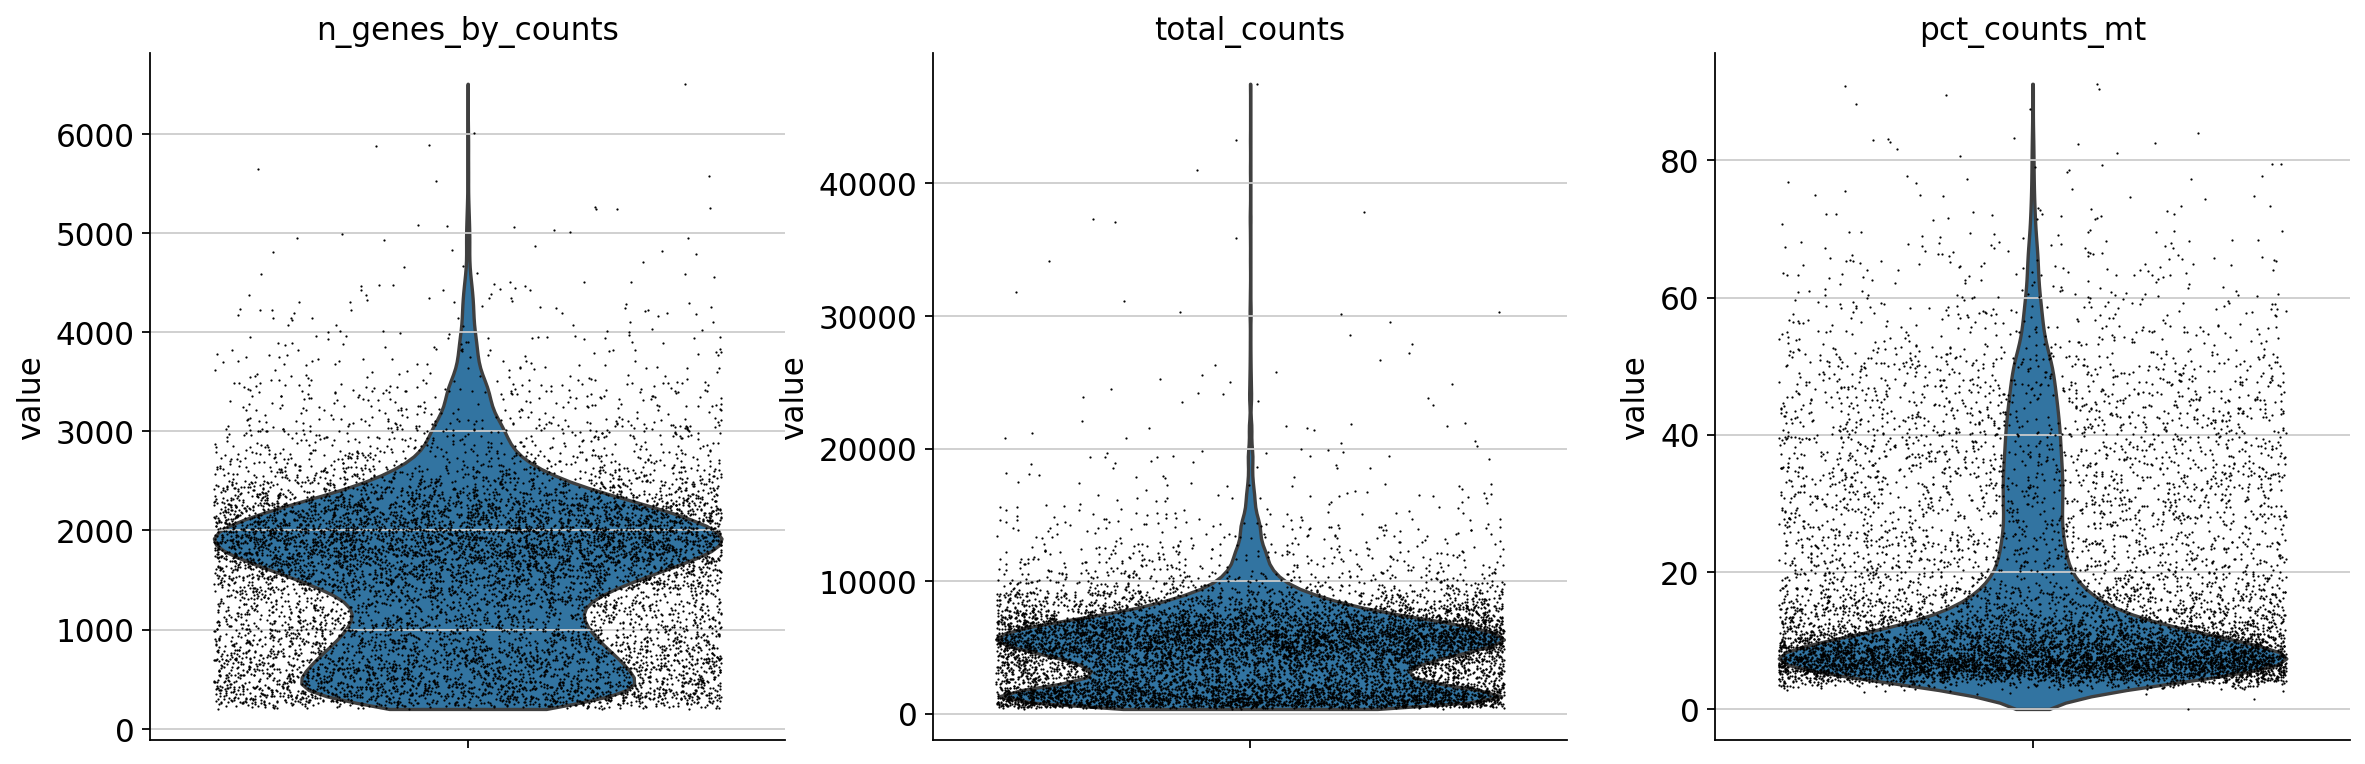

In [14]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [15]:
adata = adata[adata.obs.n_genes_by_counts > 1000, :]
adata = adata[adata.obs.pct_counts_mt < 30, :]

In [16]:
adata

View of AnnData object with n_obs × n_vars = 6869 × 29167
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

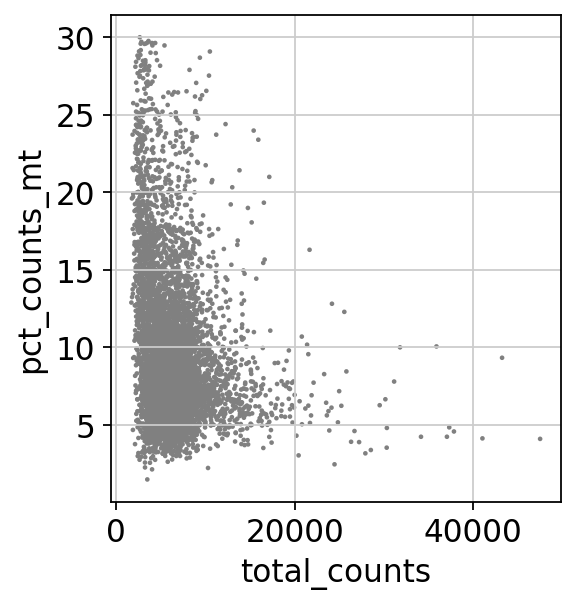

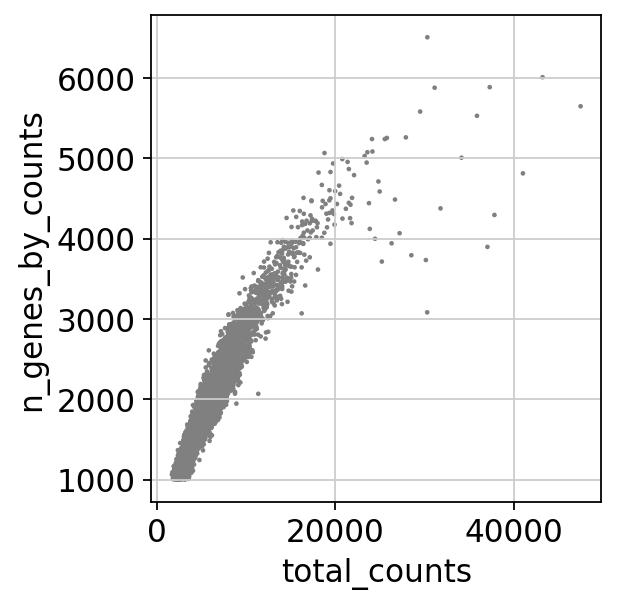

In [17]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

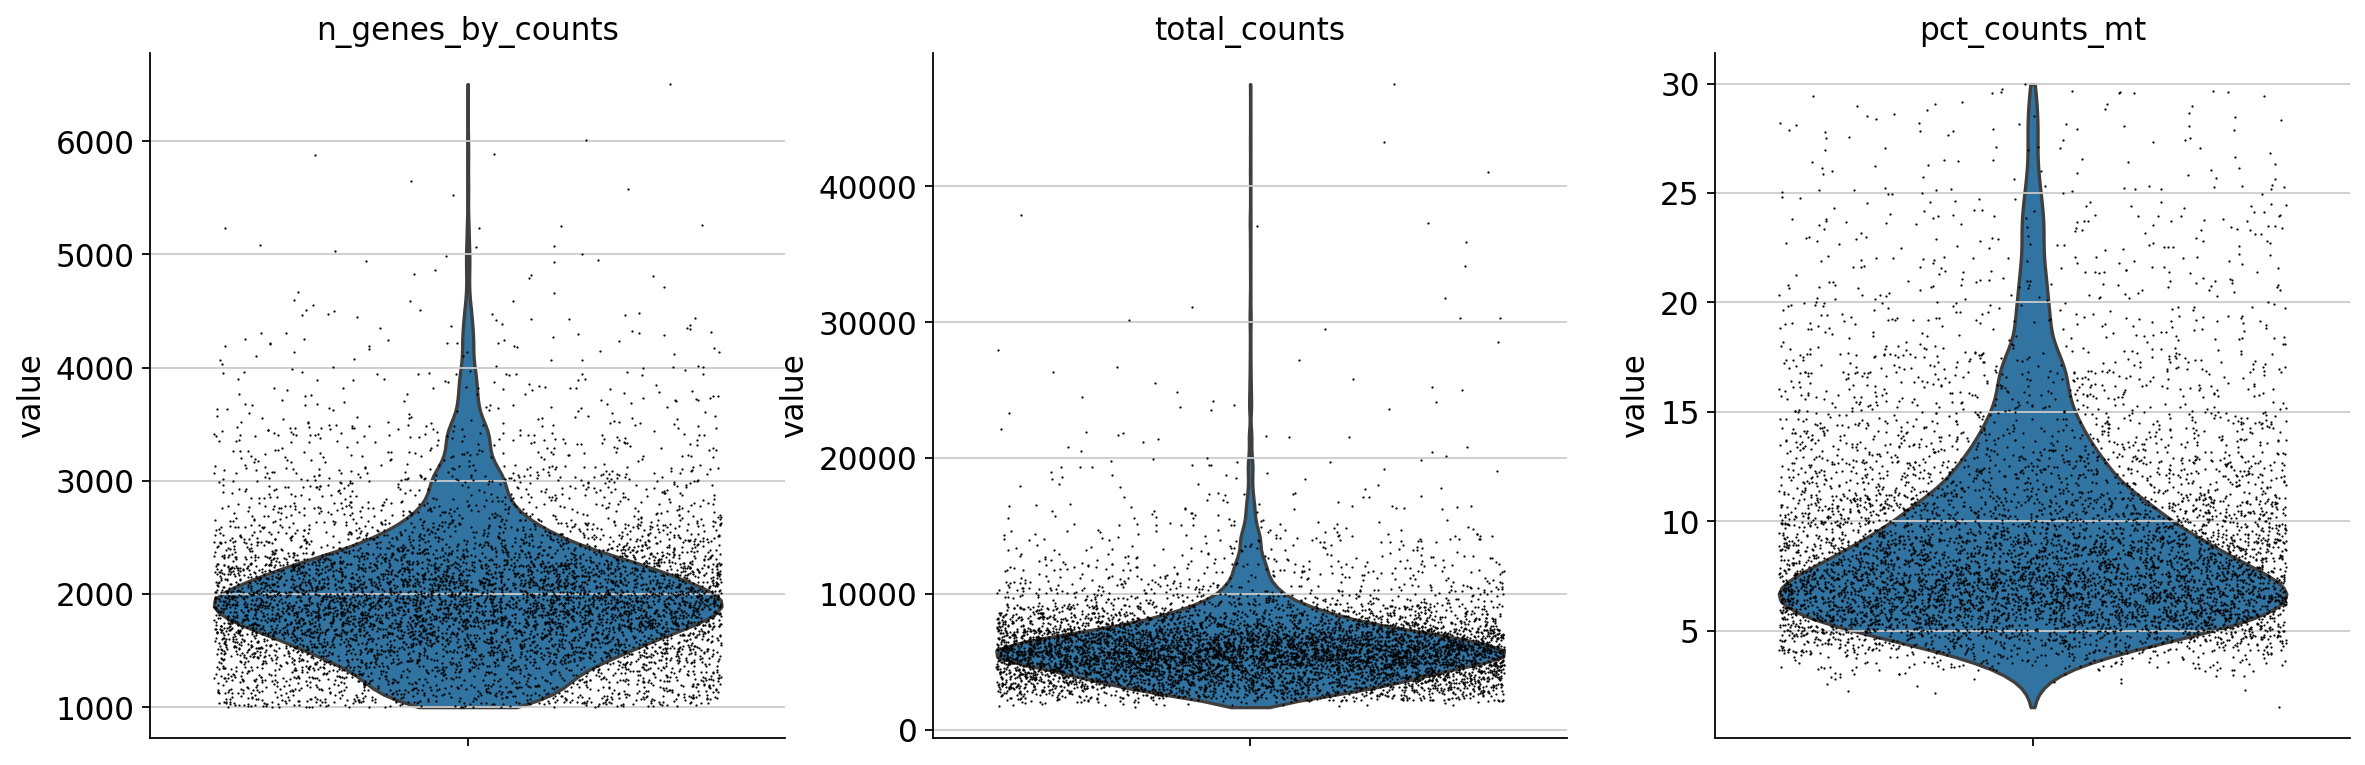

In [18]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

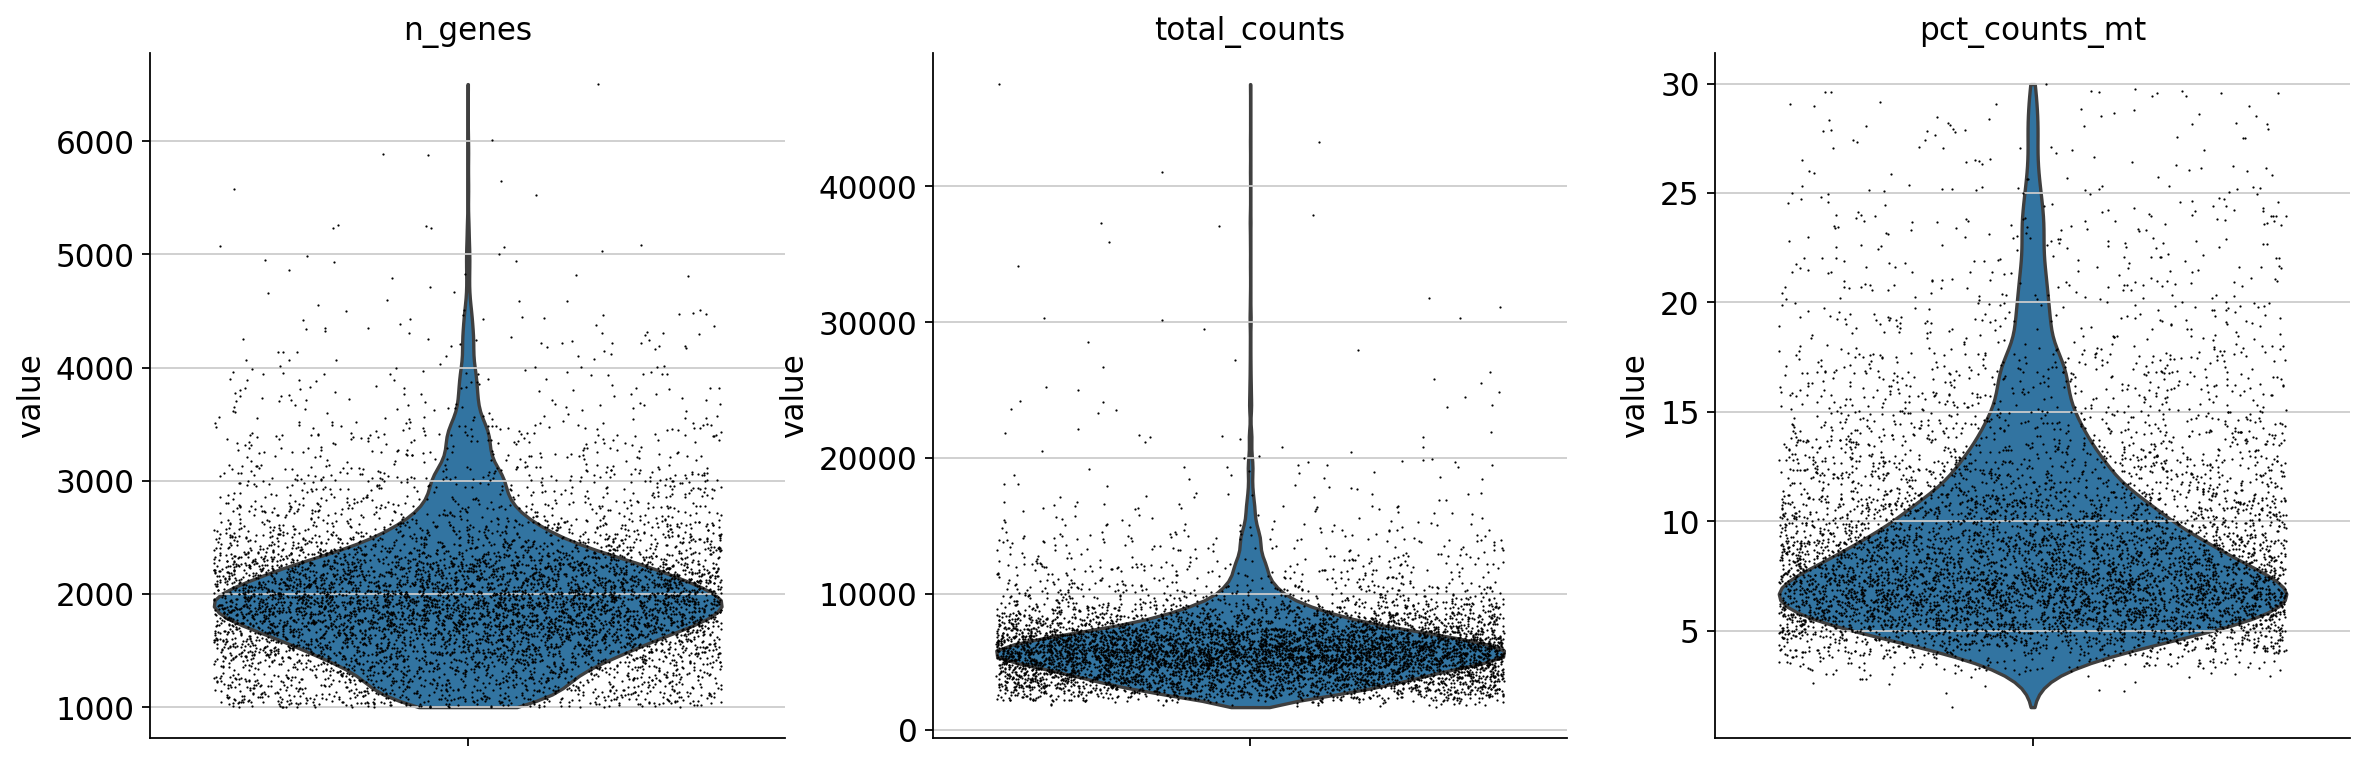

In [19]:
sc.pl.violin(adata, ['n_genes', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

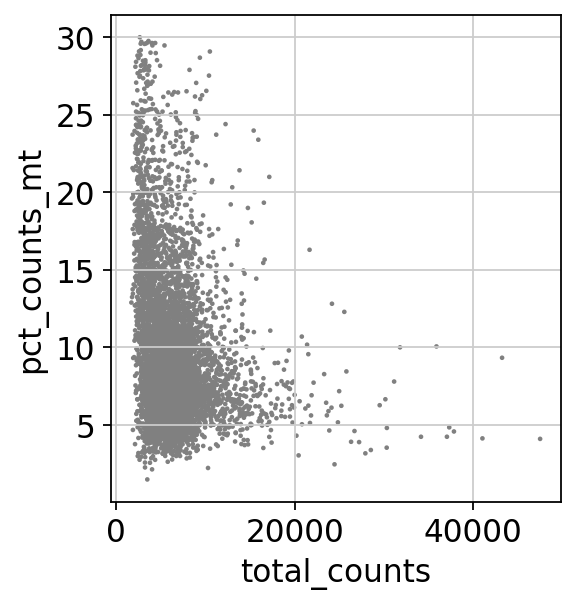

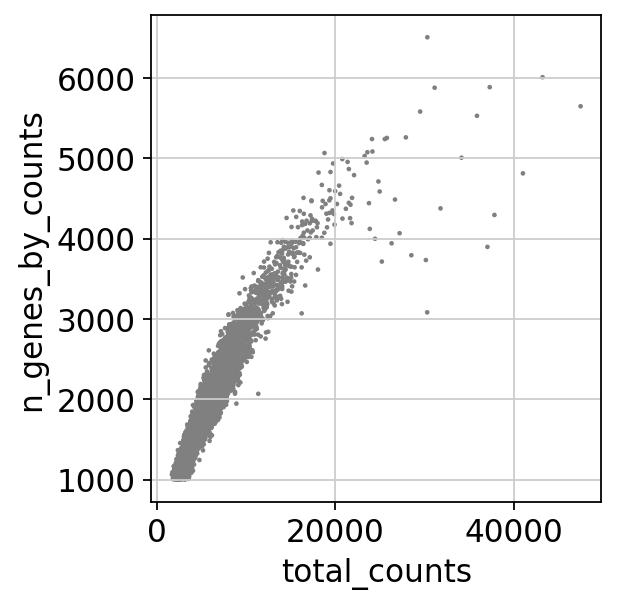

In [20]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [21]:
adata = adata[adata.obs.total_counts < 20000, :]


In [22]:
pbmc_genes=sc.get.obs_df(adata, keys=["CDKN2A_p14", "CDKN2A_p16", "CDKN2B", "CDKN2B-AS1"])

In [23]:
#adata.raw = adata

In [24]:
sc.pp.normalize_total(adata, target_sum=1e4)


normalizing counts per cell
    finished (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [25]:
sc.pp.log1p(adata)
adata.raw = adata

In [26]:
adata.obs['CDKN2A_p14_Raw']=pbmc_genes["CDKN2A_p14"]
adata.obs['CDKN2A_p16_Raw']=pbmc_genes["CDKN2A_p16"]
adata.obs['CDKN2B_p15_Raw']=pbmc_genes["CDKN2B"]
adata.obs['CDKN2B-AS1_ANRIL_Raw']=pbmc_genes["CDKN2B-AS1"]

In [27]:
sc.pp.highly_variable_genes(adata)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


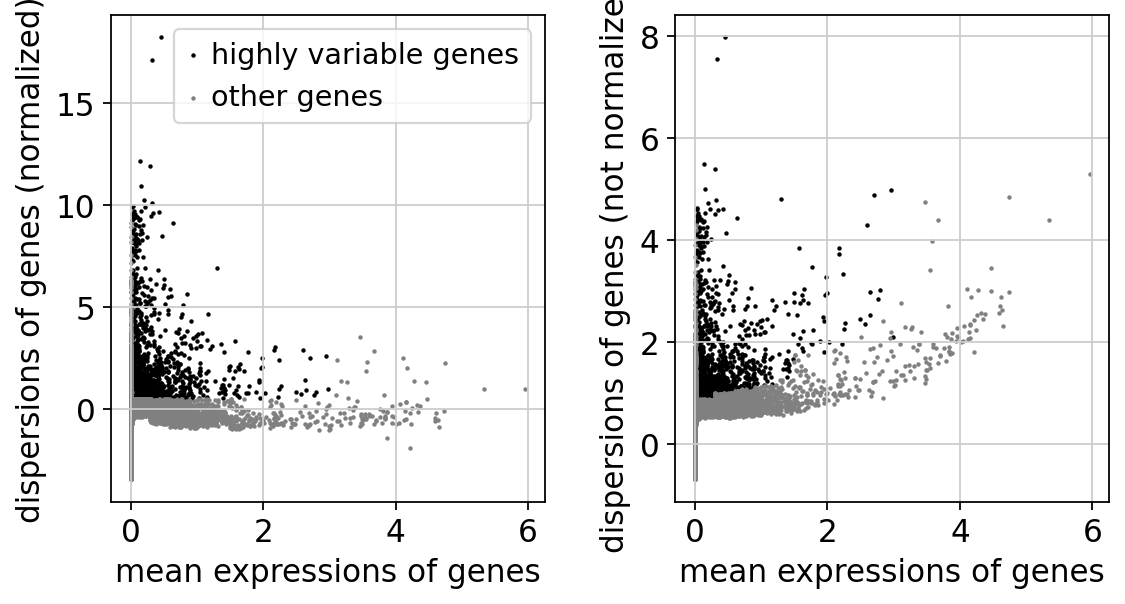

In [28]:
sc.pl.highly_variable_genes(adata)


In [29]:
sc.pp.scale(adata)


... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


In [30]:
sc.tl.pca(adata, svd_solver='arpack')


computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:01)


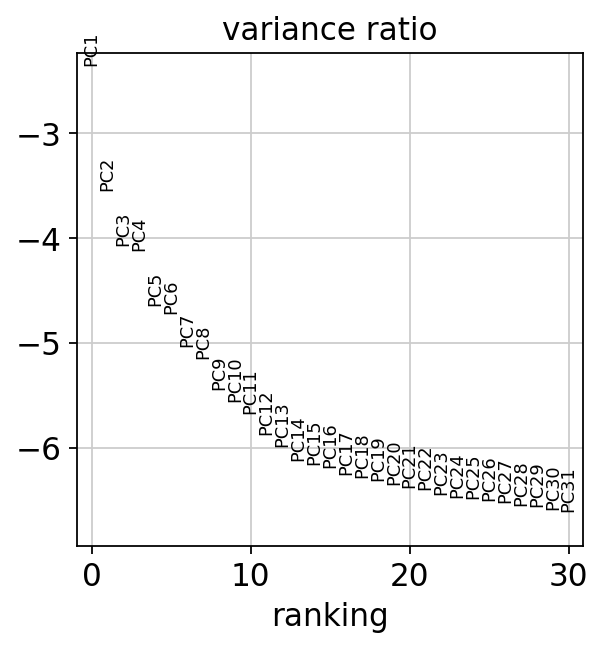

In [31]:
sc.pl.pca_variance_ratio(adata, log=True)


In [32]:
sc.pp.neighbors(adata)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)


In [33]:
sc.tl.umap(adata)


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:15)


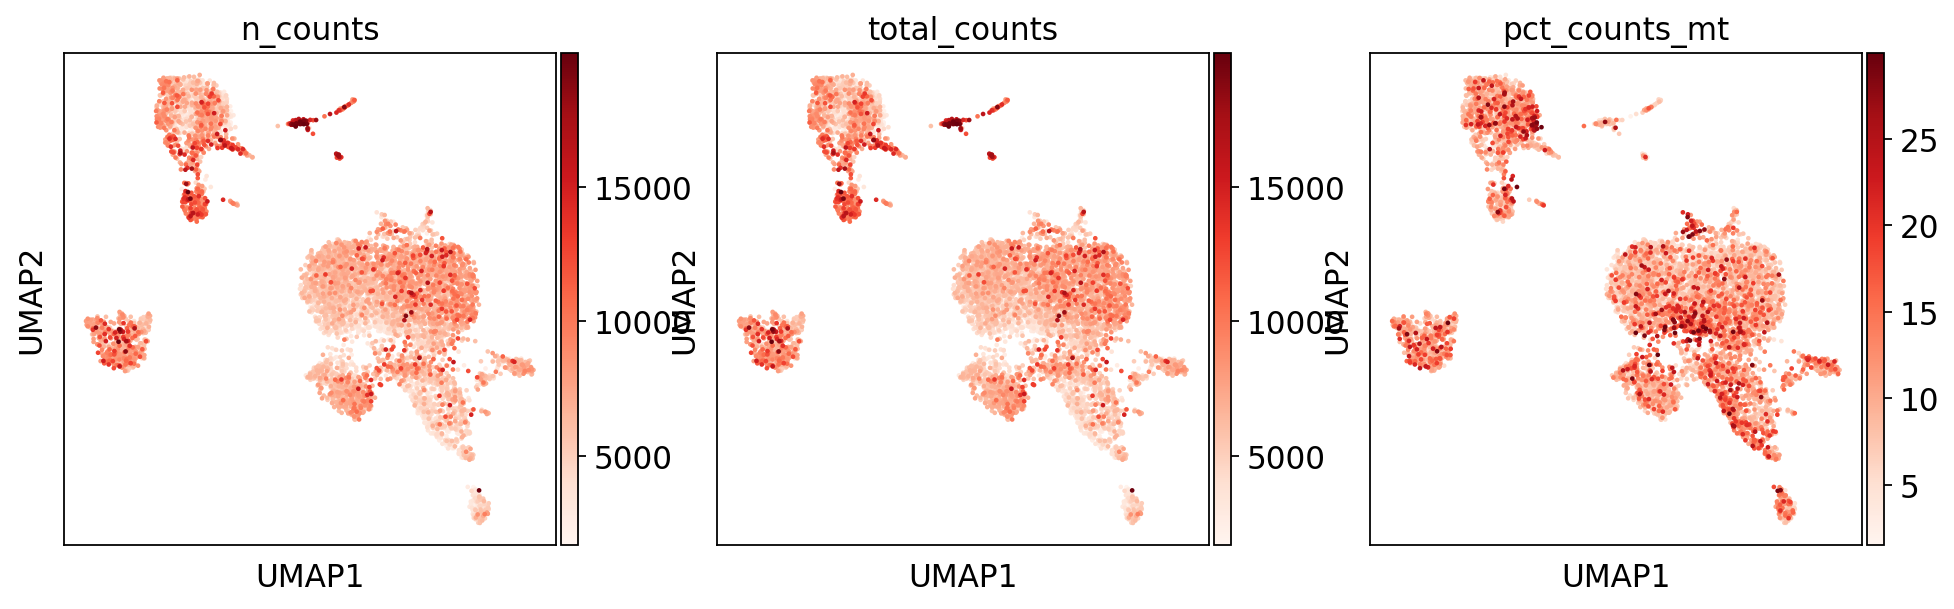

In [34]:
sc.pl.umap(adata, color=['n_counts', 'total_counts', 'pct_counts_mt'], color_map='Reds')

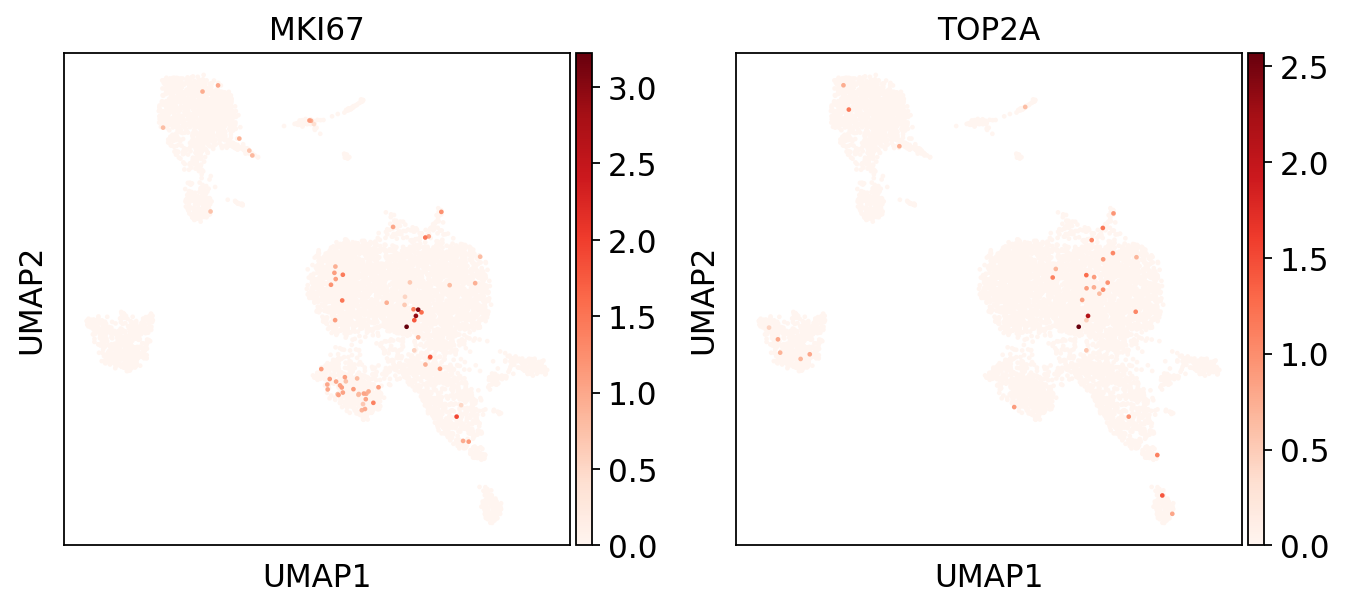

In [35]:
sc.pl.umap(adata, color=['MKI67', 'TOP2A'], color_map='Reds')

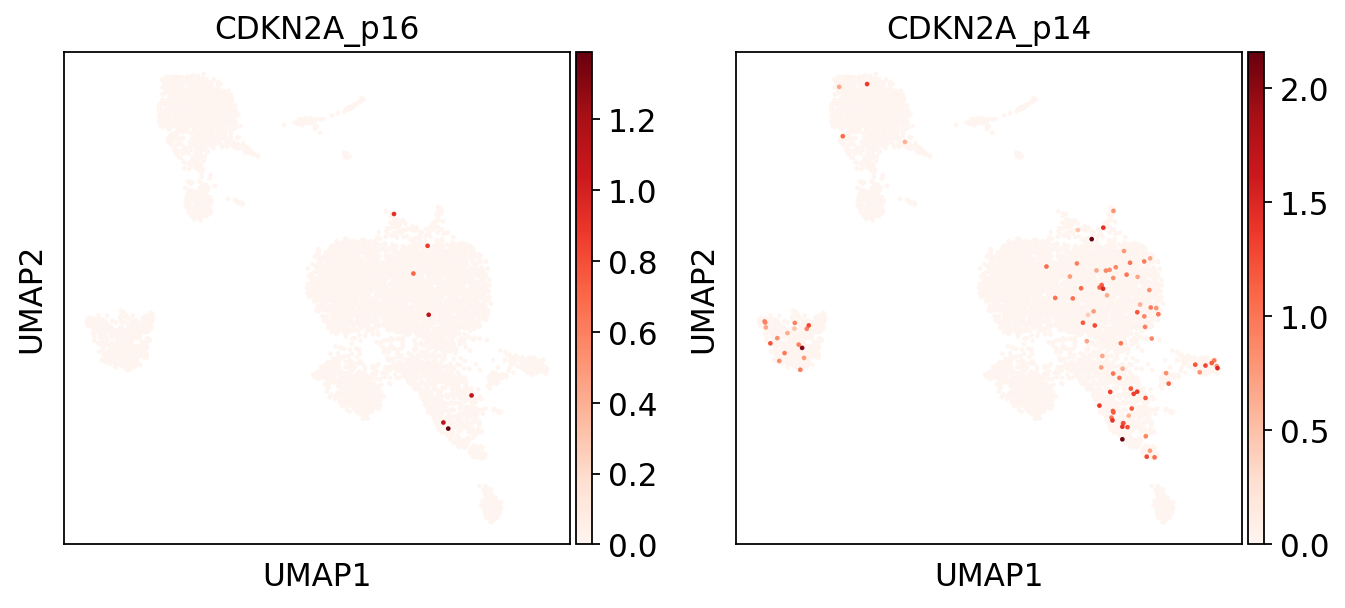

In [36]:
sc.pl.umap(adata, color=['CDKN2A_p16', 'CDKN2A_p14'], color_map='Reds')

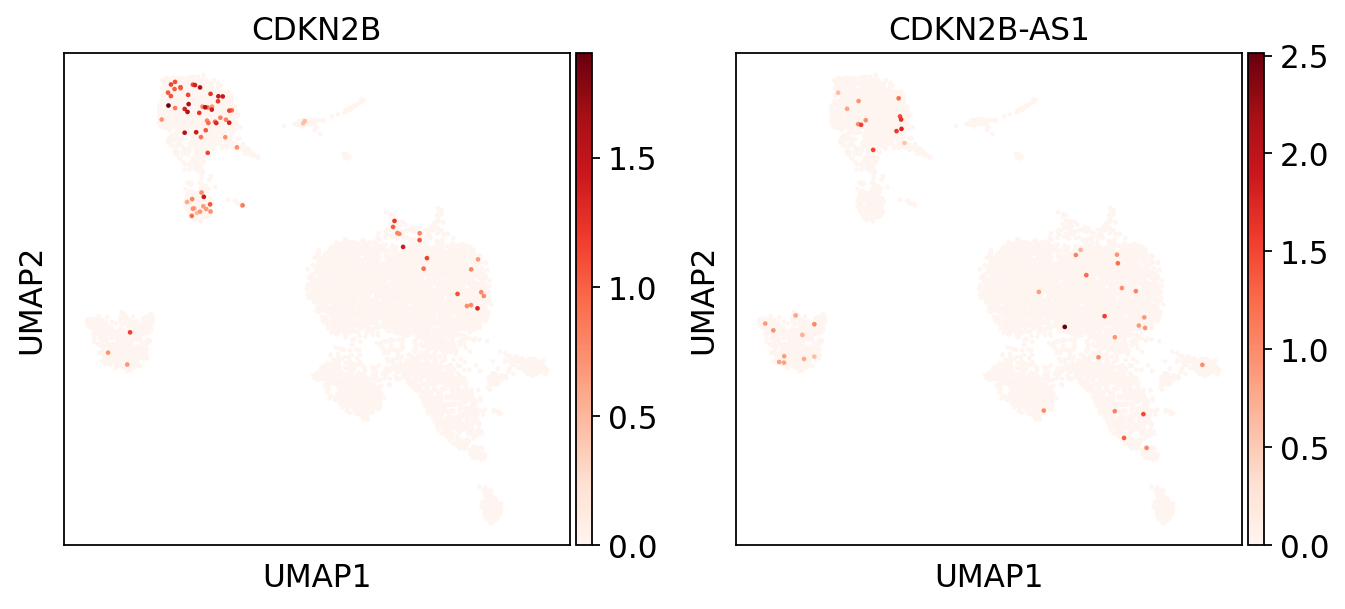

In [37]:
sc.pl.umap(adata, color=['CDKN2B', 'CDKN2B-AS1'], color_map='Reds')

In [38]:
#adata=sc.read_h5ad('/seq/epiprod02/etorlait/p16/Published_Data/10x/PBMC/adata_exploring_processed.h5ad')


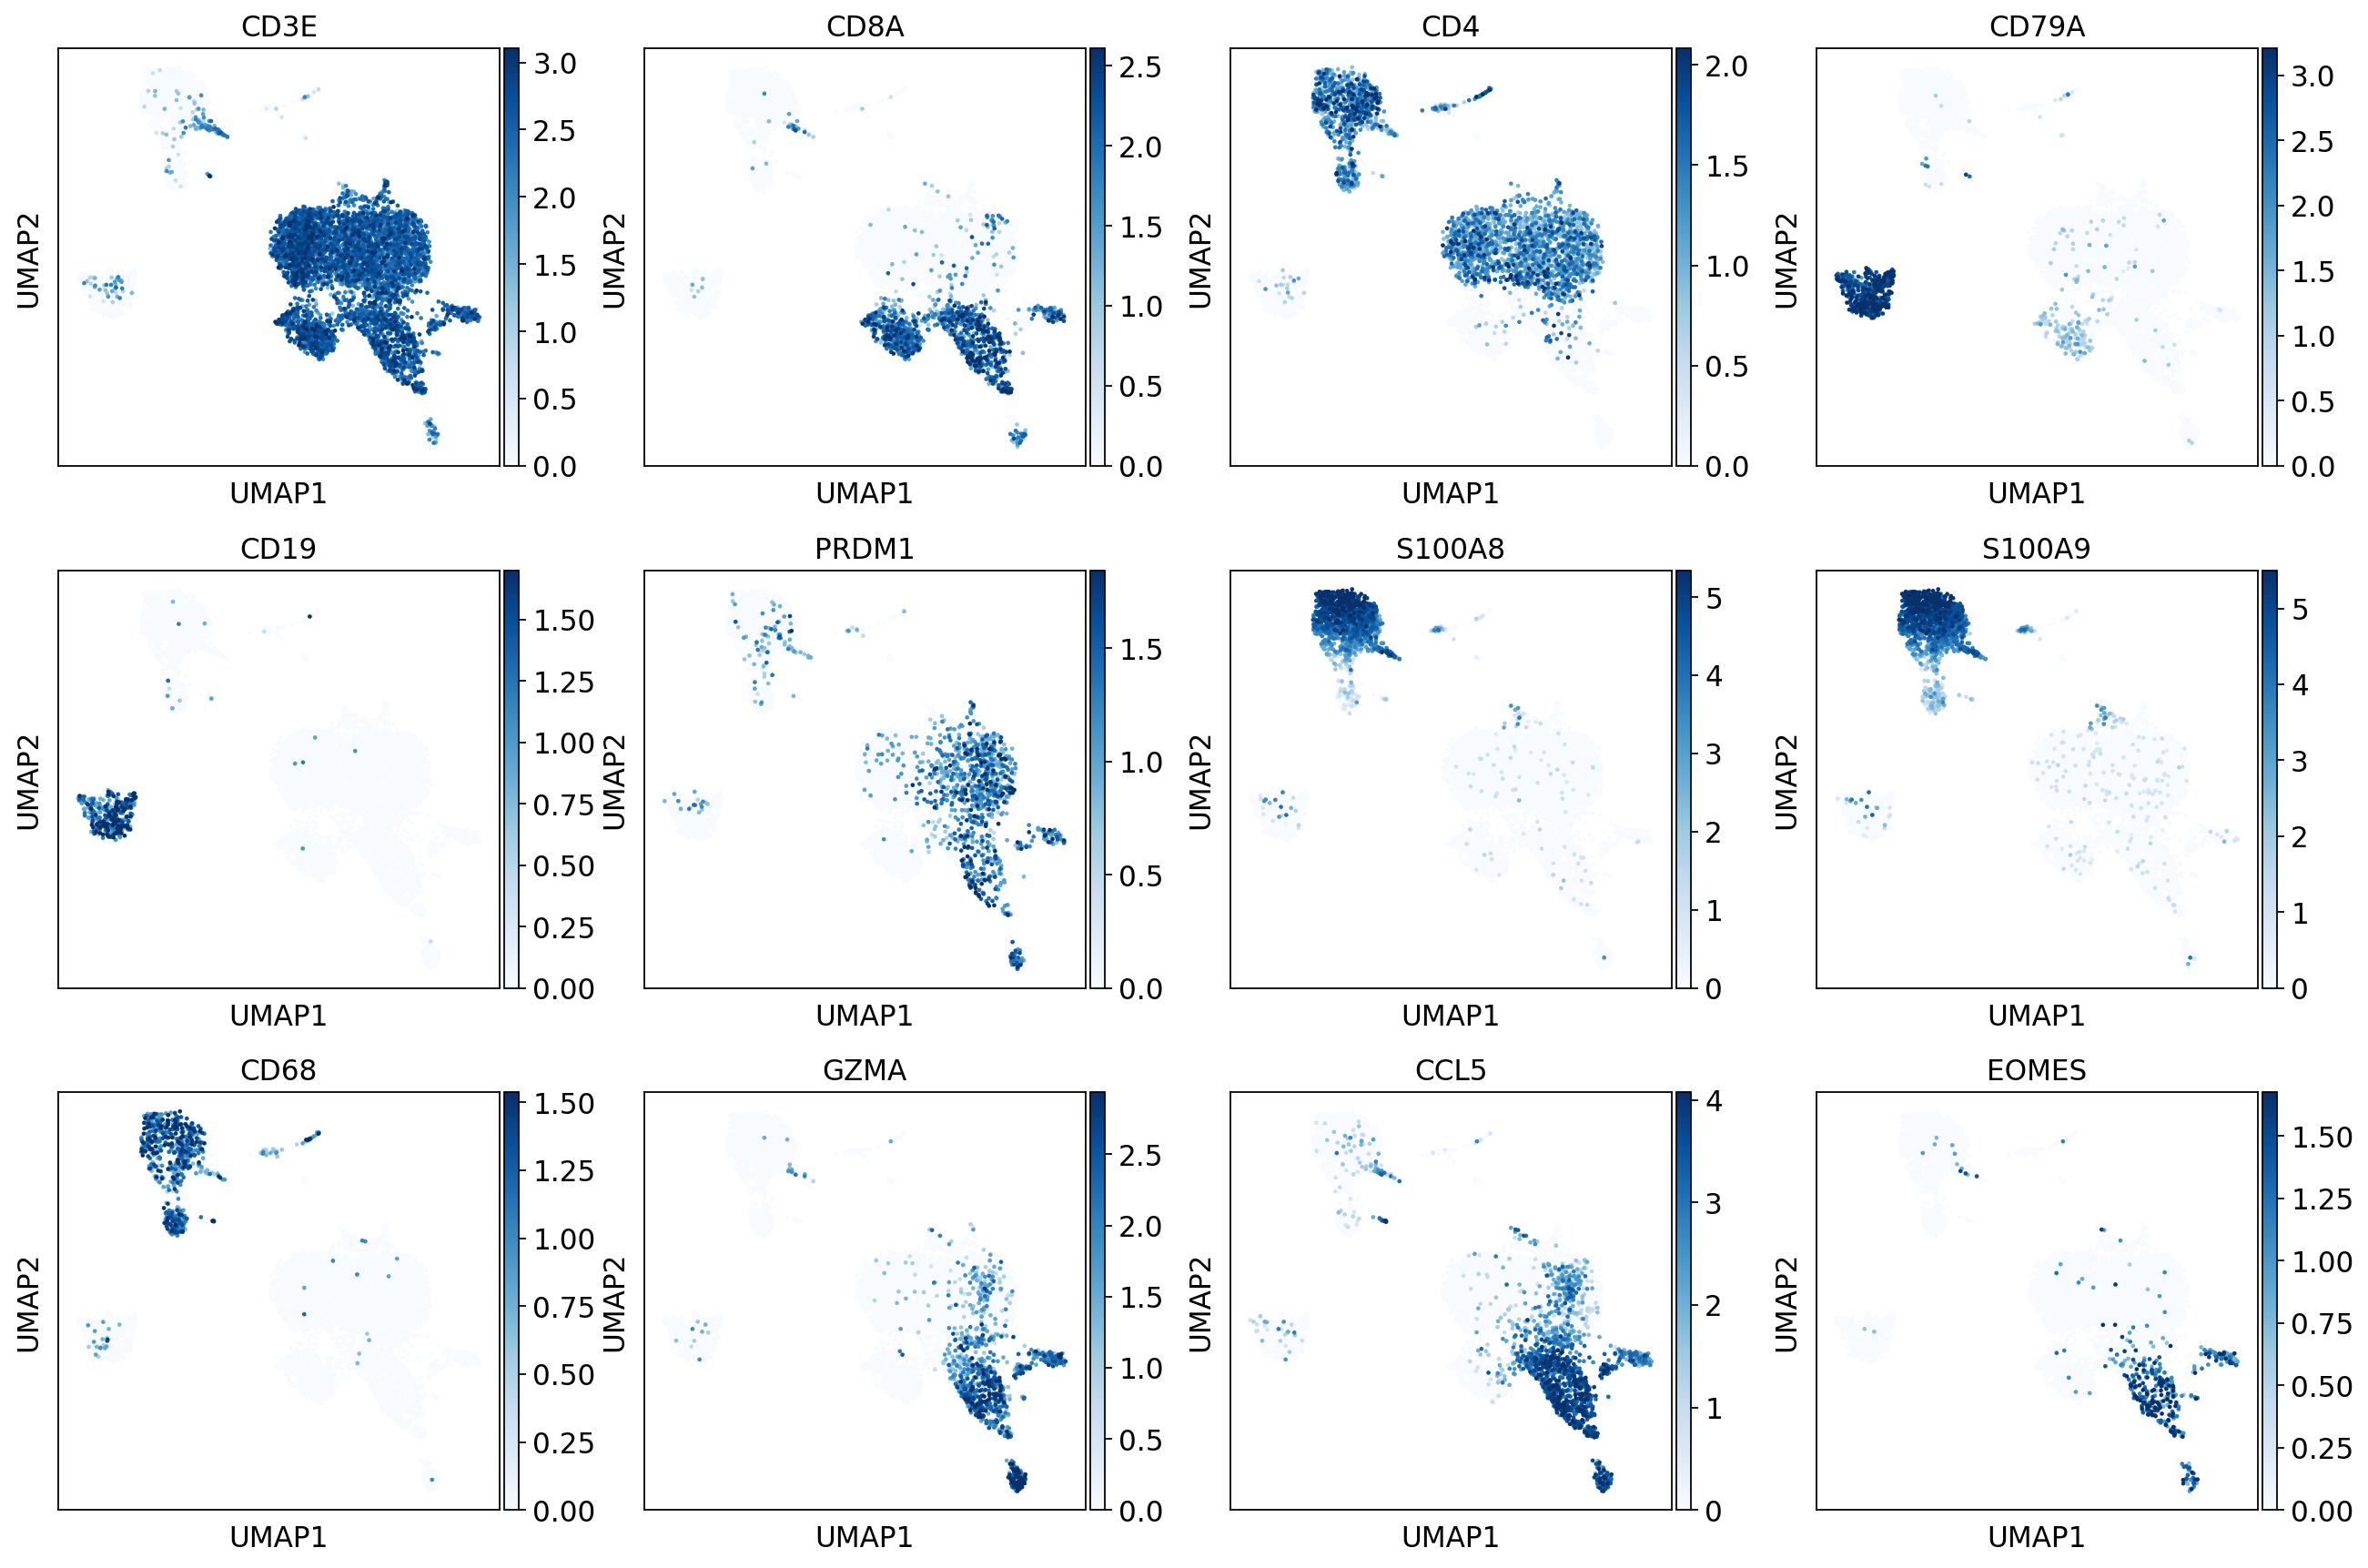

In [39]:
sc.pl.umap(adata, color=['CD3E', 'CD8A', 'CD4', 'CD79A', "CD19", "PRDM1",  'S100A8', 'S100A9', "CD68", "GZMA",  'CCL5', 'EOMES'], color_map='Blues', vmax='p99')


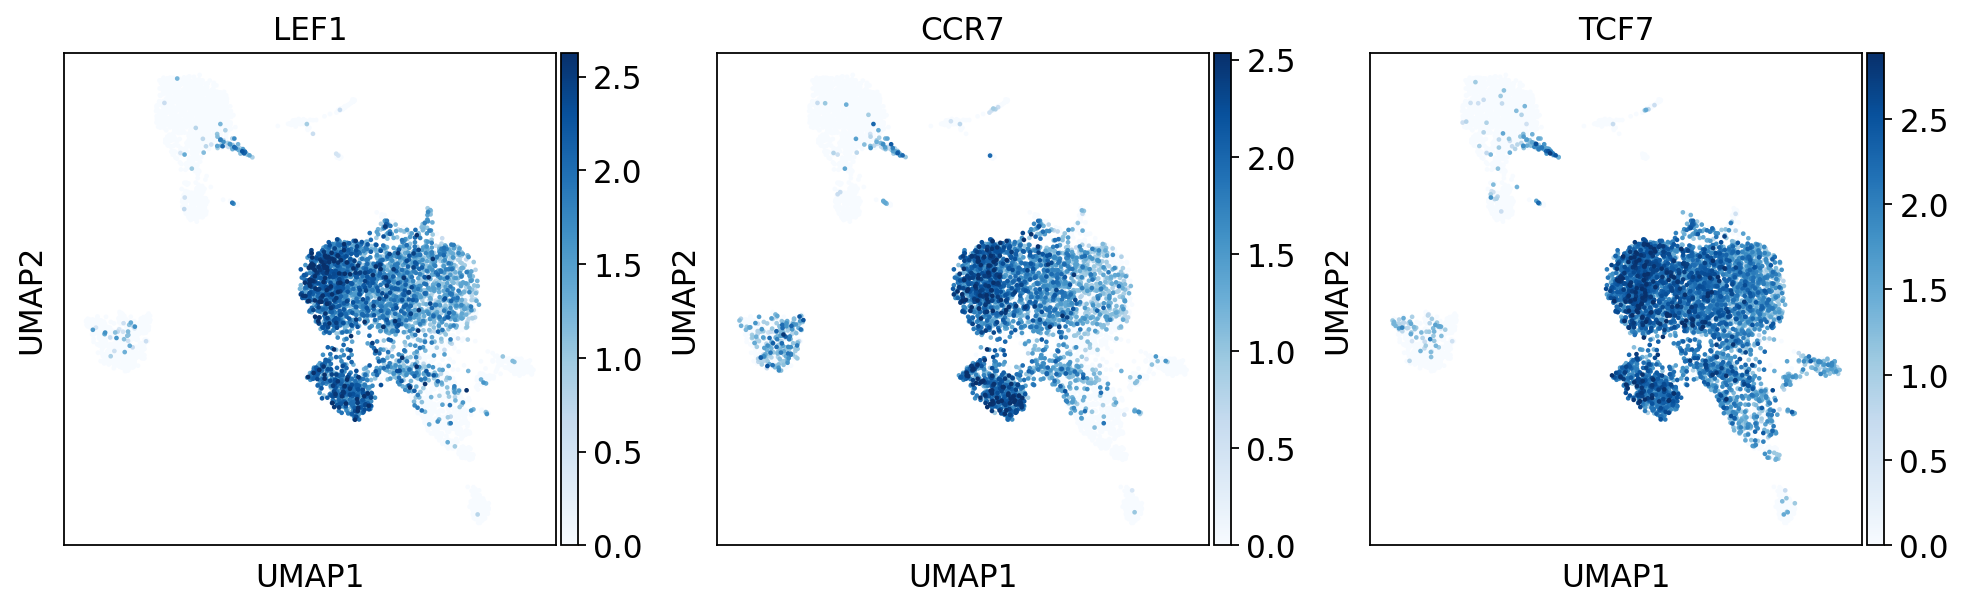

In [40]:
sc.pl.umap(adata, color=["LEF1", "CCR7", "TCF7"], color_map='Blues', vmax='p99')

In [41]:
sc.tl.leiden(adata, resolution=.099)


running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


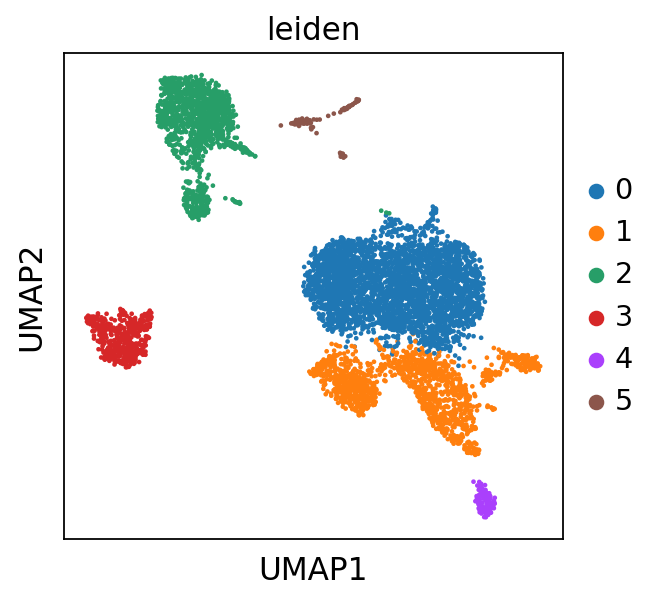

In [42]:
sc.pl.umap(adata, color=['leiden'])


In [43]:
sc.tl.rank_genes_groups(adata, groupby="leiden")


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


In [44]:
sc.get.rank_genes_groups_df(adata, group="5").head(5)


,names,scores,logfoldchanges,pvals,pvals_adj
0,CD74,34.878372,4.552038,1.776900e-59,4.627397e-57
1,HLA-DRA,29.833355,5.058976,8.368204e-52,1.768662e-49
2,HLA-DPB1,23.971109,4.037220,5.594726e-43,9.167493e-41
3,HLA-DPA1,23.565424,4.327353,2.971930e-42,4.736737e-40
4,HLA-DRB1,22.580761,4.125614,8.984429e-41,1.316828e-38


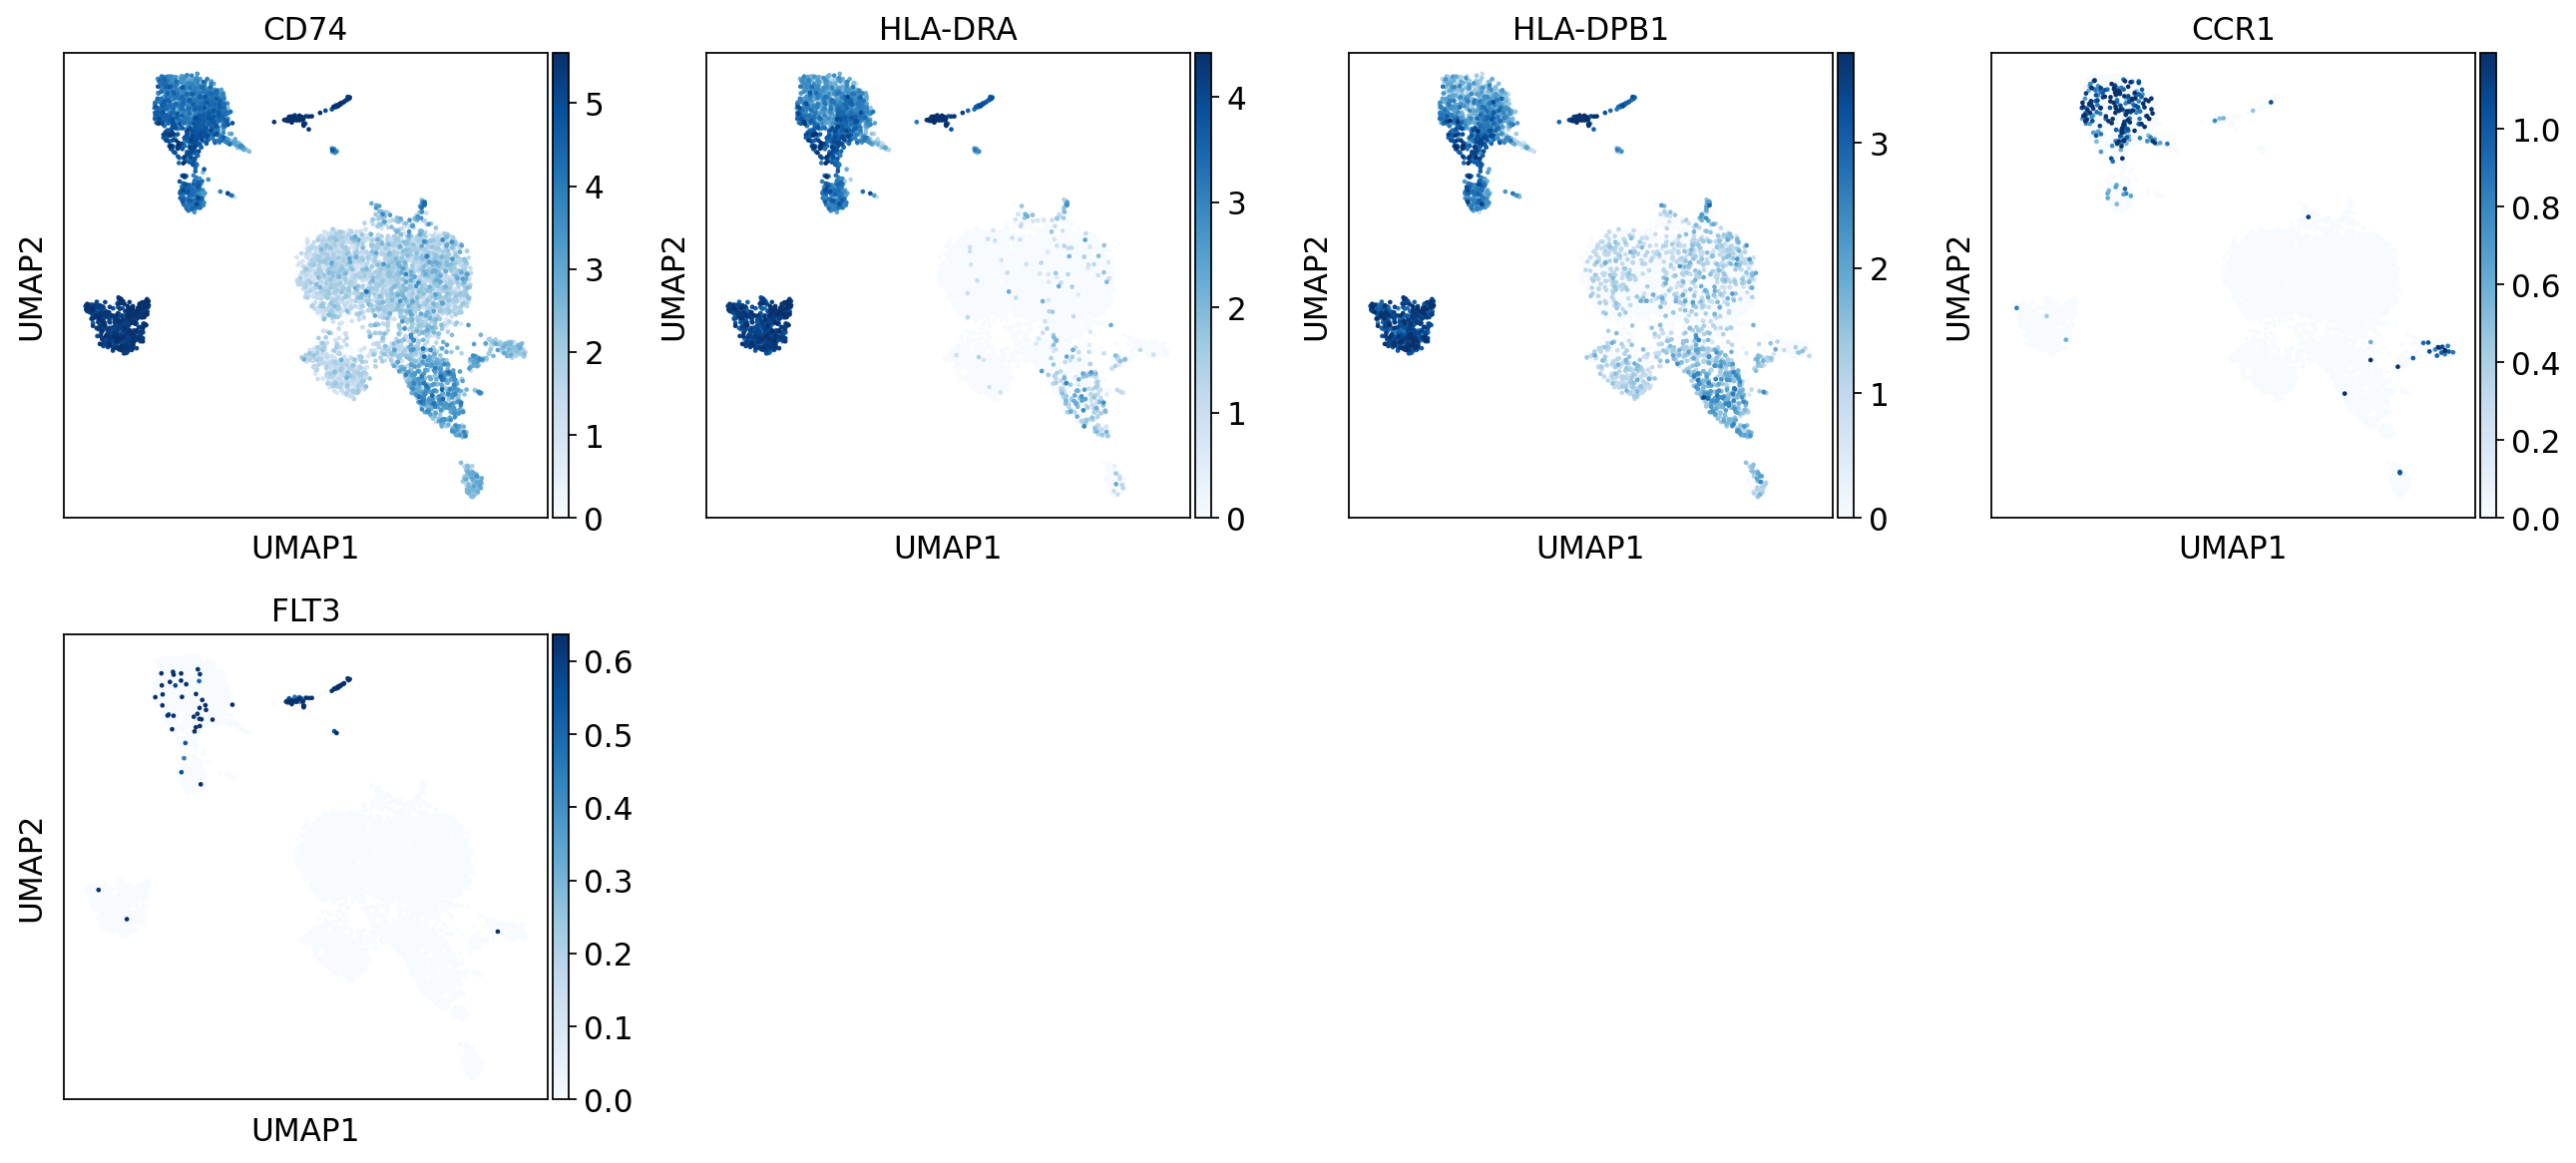

In [45]:
sc.pl.umap(adata, color=["CD74", "HLA-DRA", "HLA-DPB1", "CCR1", "FLT3"], color_map='Blues', vmax='p99')

In [46]:
adata.obs["cellType"] = adata.obs["leiden"].map(
    {
        "0": "CD4_Tcells",
        "1": "CD8_Tcells",
        "2": "PMN_Macroph",
        "3": "Bcells",
        "4": "NKcells",
        "5": "DCs",
    }
)

adata.obs["cellType2"] = adata.obs["leiden"].map(
    {
        "0": "Tcells",
        "1": "Tcells",
        "2": "Myeloid",
        "3": "Bcells",
        "4": "NKcells",
        "5": "Myeloid",
    }
)

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


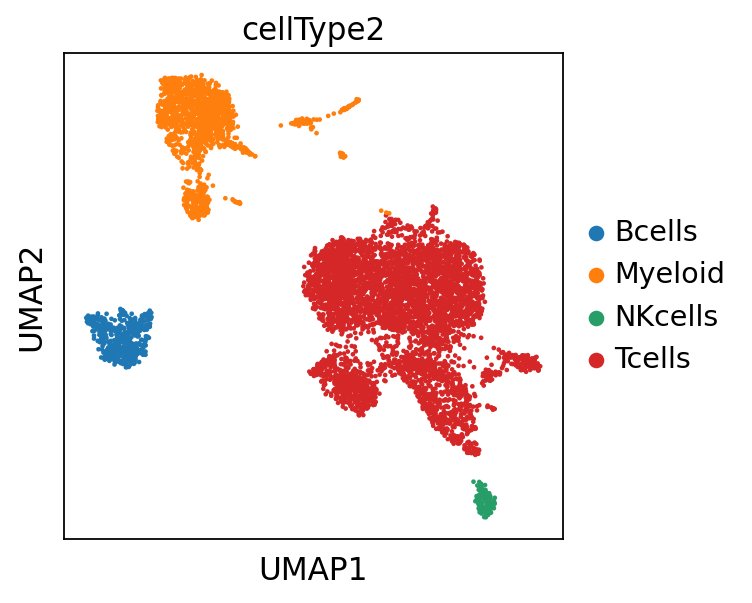

In [54]:
sc.pl.umap(adata, color=["cellType2"], save='PBMC_10x_CellTypes.pdf')

In [48]:
adata.write('/seq/epiprod02/etorlait/p16/Published_Data/10x/STARsolo_verB/pbmc_adata_exploring_processed_newFilt_forGH.h5ad')



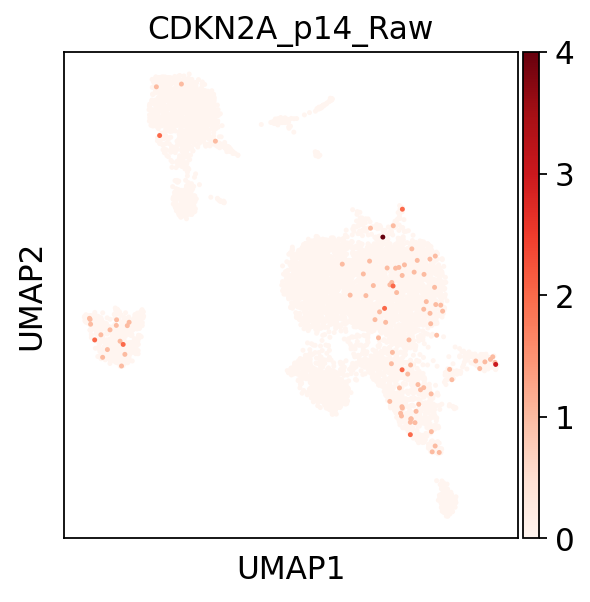

In [55]:
sc.pl.umap(adata, color=["CDKN2A_p14_Raw"], size=20, color_map='Reds', 
           save='PBMC_10x_CDKN2A_p14_RawCounts.pdf')

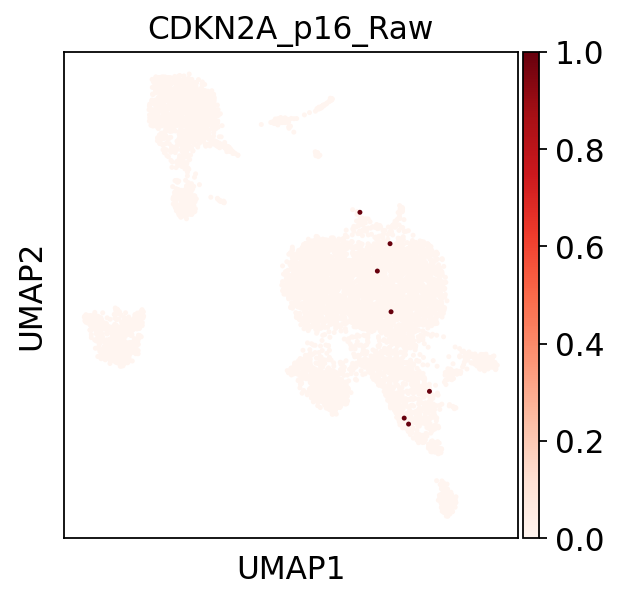

In [56]:
sc.pl.umap(adata, color=["CDKN2A_p16_Raw"], size=20, color_map='Reds', save='PBMC_10x_CDKN2A_p16_RawCounts.pdf')

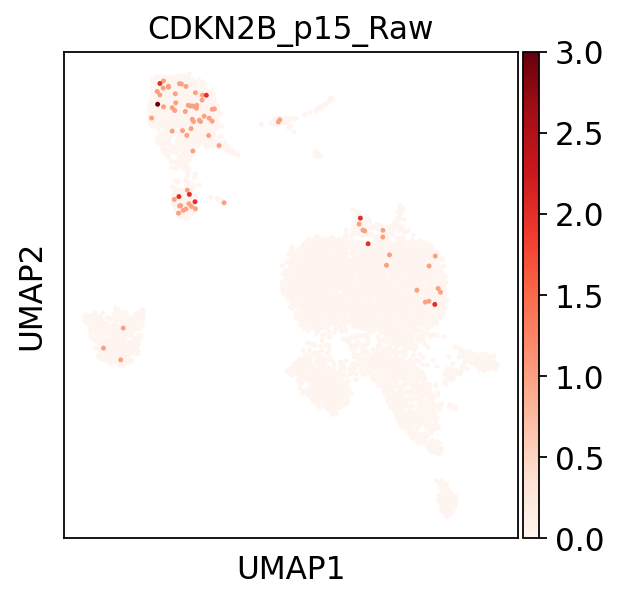

In [57]:
sc.pl.umap(adata, color=["CDKN2B_p15_Raw"],  size=20, color_map='Reds', save='PBMC_10x_CDKN2B_p15_RawCounts.pdf')

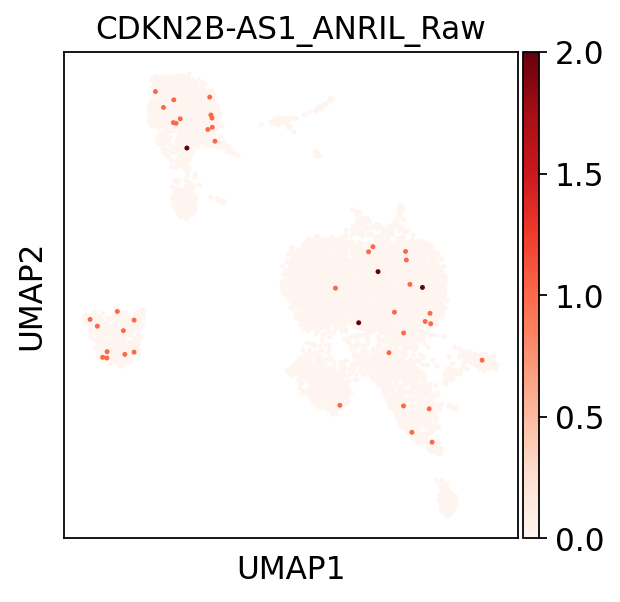

In [58]:
sc.pl.umap(adata, color=["CDKN2B-AS1_ANRIL_Raw"],  size=20, color_map='Reds', 
           save='PBMC_10x_CDKN2B-AS1_ANRIL_RawCounts.pdf')


In [59]:
adata_test= sc.get.obs_df(adata,
        keys=['cellType2','CDKN2A_p14_Raw', 'CDKN2A_p16_Raw', 'CDKN2B_p15_Raw', 'CDKN2B-AS1_ANRIL_Raw'],use_raw=True)
adata_test

,cellType2,CDKN2A_p14_Raw,CDKN2A_p16_Raw,CDKN2B_p15_Raw,CDKN2B-AS1_ANRIL_Raw
AAACCTGAGACTTTCG,Tcells,0.0,0.0,0.0,0.0
AAACCTGAGGCGACAT,Tcells,0.0,0.0,0.0,0.0
AAACCTGCATATACGC,Tcells,0.0,0.0,0.0,0.0
AAACCTGCATATGCTG,Tcells,0.0,0.0,0.0,0.0
AAACCTGCATTTGCCC,Tcells,0.0,0.0,0.0,0.0
...,...,...,...,...,...
TTTGTCATCAGCCTAA,Bcells,0.0,0.0,0.0,0.0
TTTGTCATCGACGGAA,Tcells,0.0,0.0,0.0,0.0
TTTGTCATCGGAAACG,Tcells,0.0,0.0,0.0,0.0
TTTGTCATCGTAGGTT,Bcells,0.0,0.0,0.0,0.0


In [60]:
adata_test=adata_test.rename(columns={'cellType2':'cellType', 
                                     "CDKN2A_p14_Raw":"CDKN2A_p14", 
                                     "CDKN2A_p16_Raw":"CDKN2A_p16", 
                                     "CDKN2B_p15_Raw": "CDKN2B", 
                                     "CDKN2B-AS1_ANRIL_Raw": "CDKN2B-AS1"})

In [61]:
adata_test.max()

/local/scratch/53448706.1.broad/ipykernel_89721/2692591866.py:1: FutureWarning: The default value of numeric_only in DataFrame.max is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  adata_test.max()


CDKN2A_p14    4.0
CDKN2A_p16    1.0
CDKN2B        3.0
CDKN2B-AS1    2.0
dtype: float32

In [62]:
adata_test.to_csv('/seq/epiprod02/etorlait/p16/Published_Data/10x/STARsolo_verB/pbmc_adata_exploring_processed_newFilt_9p21genes_rawValues.tsv', sep='\t')

In [63]:
new_order=['Tcells', 'NKcells','Bcells','Myeloid']
adata_test['cellType'] = adata_test['cellType'].cat.reorder_categories(new_order, ordered=True)

In [64]:
total_counts_sc1 = adata_test.groupby('cellType').size()
total_counts_sc1


cellType
Tcells     4843
NKcells     109
Bcells      469
Myeloid    1402
dtype: int64

In [65]:
##p14

# Count rows where Value > threshold per Category
above_threshold_counts_p14_sc1 = adata_test[adata_test['CDKN2A_p14'] > 0].groupby('cellType').size()

# Calculate percentage of rows > threshold per Category
percentage_above_threshold_p14_sc1 = (above_threshold_counts_p14_sc1 / total_counts_sc1) * 100


In [66]:
above_threshold_counts_p14_sc1


cellType
Tcells     75
NKcells     0
Bcells     16
Myeloid     4
dtype: int64

In [67]:
percentage_above_threshold_p14_sc1


cellType
Tcells     1.548627
NKcells    0.000000
Bcells     3.411514
Myeloid    0.285307
dtype: float64

In [68]:
##p16

# Count rows where Value > threshold per Category
above_threshold_counts_p16_sc1 = adata_test[adata_test['CDKN2A_p16'] > 0].groupby('cellType').size()

# Calculate percentage of rows > threshold per Category
percentage_above_threshold_p16_sc1 = (above_threshold_counts_p16_sc1 / total_counts_sc1) * 100


In [69]:
above_threshold_counts_p16_sc1

cellType
Tcells     6
NKcells    0
Bcells     0
Myeloid    1
dtype: int64

In [70]:
percentage_above_threshold_p16_sc1

cellType
Tcells     0.123890
NKcells    0.000000
Bcells     0.000000
Myeloid    0.071327
dtype: float64

In [71]:

##p15

# Count rows where Value > threshold per Category
above_threshold_counts_p15_sc1 = adata_test[adata_test['CDKN2B'] > 0].groupby('cellType').size()

# Calculate percentage of rows > threshold per Category
percentage_above_threshold_p15_sc1 = (above_threshold_counts_p15_sc1 / total_counts_sc1) * 100


In [72]:
above_threshold_counts_p15_sc1

cellType
Tcells     17
NKcells     0
Bcells      3
Myeloid    59
dtype: int64

In [73]:
percentage_above_threshold_p15_sc1

cellType
Tcells     0.351022
NKcells    0.000000
Bcells     0.639659
Myeloid    4.208274
dtype: float64

In [74]:

##ANRIL

# Count rows where Value > threshold per Category
above_threshold_counts_ANRIL_sc1 = adata_test[adata_test['CDKN2B-AS1'] > 0].groupby('cellType').size()

# Calculate percentage of rows > threshold per Category
percentage_above_threshold_ANRIL_sc1 = (above_threshold_counts_ANRIL_sc1 / total_counts_sc1) * 100


In [75]:
above_threshold_counts_ANRIL_sc1


cellType
Tcells     21
NKcells     0
Bcells     10
Myeloid    13
dtype: int64

In [76]:
percentage_above_threshold_ANRIL_sc1

cellType
Tcells     0.433616
NKcells    0.000000
Bcells     2.132196
Myeloid    0.927247
dtype: float64

<Figure size 1000x600 with 0 Axes>

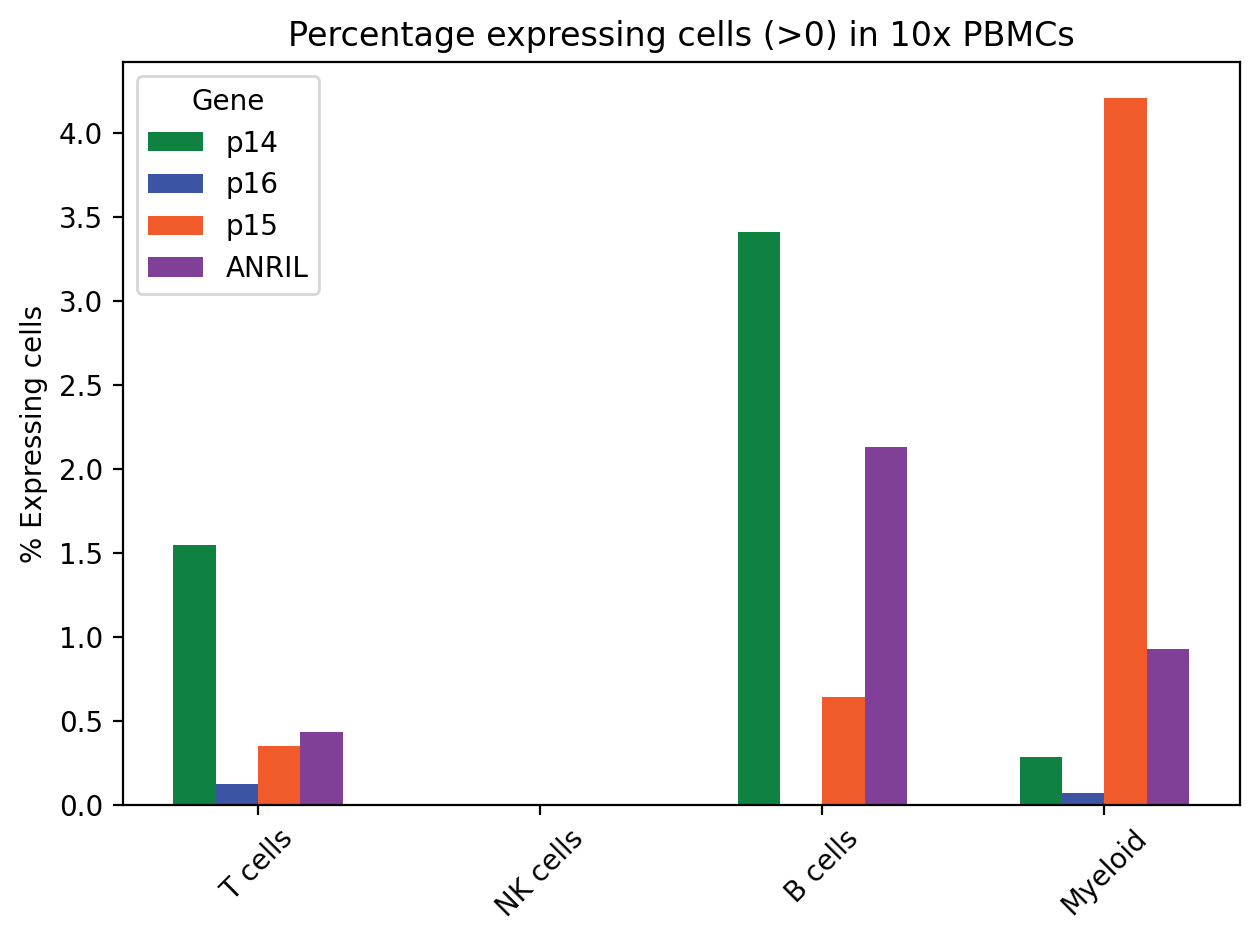

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.style.use('default')

groups = ['T cells', 'NK cells', 'B cells', 'Myeloid']
# Bar width and positions
x = np.arange(len(groups))  # [0, 1, 2, 3, 4]
width = 0.15

colors = ['#0F8141','#3C54A4', '#F15A2B', '#804098']

fig, ax = plt.subplots()
ax.bar(x - 1.5*width, np.array(percentage_above_threshold_p14_sc1.values), width, label='p14',color=colors[0])
ax.bar(x - 0.5*width, np.array(percentage_above_threshold_p16_sc1.values), width, label='p16', color=colors[1])
ax.bar(x + 0.5*width, np.array(percentage_above_threshold_p15_sc1.values), width, label='p15', color=colors[2])
ax.bar(x + 1.5*width, np.array(percentage_above_threshold_ANRIL_sc1.values), width, label='ANRIL', color=colors[3])

ax.set_xticks(x)
ax.set_xticklabels(groups)
plt.xticks(rotation=45)
ax.set_ylabel('% Expressing cells')
ax.legend()


# Final plot formatting
plt.ylabel('% Expressing cells')
plt.title('Percentage expressing cells (>0) in 10x PBMCs')
plt.xticks(ticks=range(len(groups)), labels=groups)
plt.xticks(rotation=45)

plt.legend(title='Gene')
plt.tight_layout()

plt.savefig("/seq/epiprod02/etorlait/p16/Published_Data/10x/STARsolo_verB/pbmc_adata_PercentExpressing_GroupedBarplot_NewGroups_Order.pdf", format='pdf', dpi=300)
